<a href="https://colab.research.google.com/github/PreethiR091/Deep-Learning/blob/main/Preethi_R_24BAD091_DL_Ex_no_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPT NO: 4 - TRANSFER LEARNING USING PRE-TRAINED VISION MODELS FOR IMAGE RECOGNITION

Task A: DATASET PREPARATION

Perform the following tasks:

    •	Download an image dataset from Kaggle.
    •	Load and preprocess the images.
    •	Split the dataset into training, validation, and testing sets.


Preethi R - 24BAD091


Saving flowers.zip to flowers (1).zip

ZIP file extracted successfully.
Dataset path: /content/flower_data/flowers

Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

Number of images in each class:
daisy: 764
dandelion: 1052
rose: 784
sunflower: 733
tulip: 984


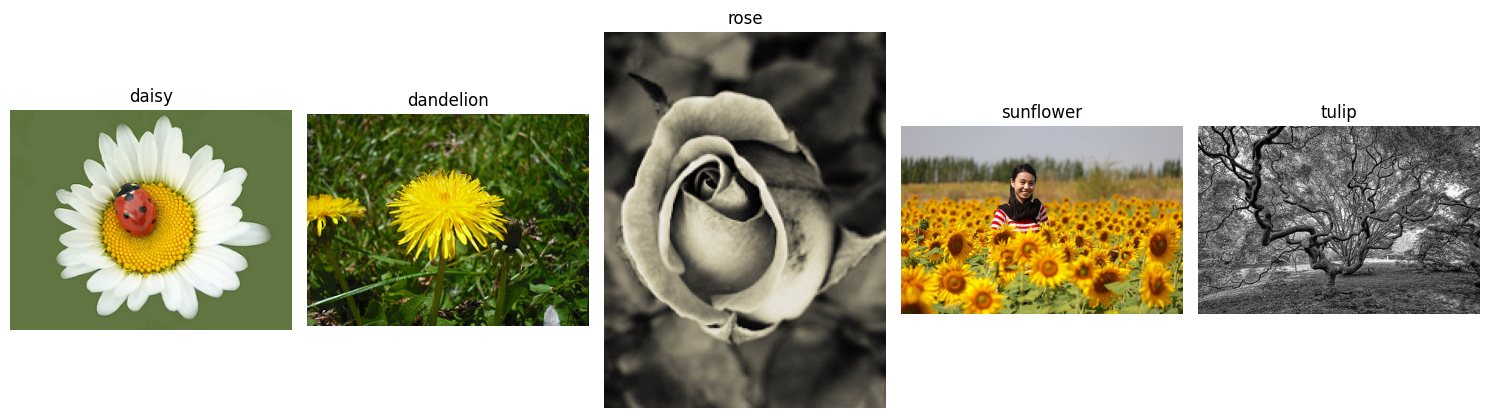

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.

Class names: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5

Dataset split completed.
Training data  : approximately 80%
Validation data: approximately 10%
Testing data   : approximately 10%

Task A completed successfully.


In [5]:
# EXPERIMENT NO: 4
# TASK A: DATASET PREPARATION
# Student Name: Preethi R
# Roll No: 24BAD091


import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files

print("Preethi R - 24BAD091")

# Upload ZIP file
uploaded = files.upload()

# Get uploaded ZIP file name
zip_path = next(iter(uploaded))

# Extract ZIP file
extract_path = "/content/flower_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("\nZIP file extracted successfully.")

# Find the actual dataset folder automatically
expected_classes = {"daisy", "dandelion", "rose", "sunflower", "tulip"}

dataset_path = None

for root, dirs, file_names in os.walk(extract_path):
    if expected_classes.issubset(set(dirs)):
        dataset_path = root
        break

if dataset_path is None:
    raise FileNotFoundError(
        "Could not find the Flowers dataset with the expected class folders."
    )

print("Dataset path:", dataset_path)

# Display class names
class_names = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("\nClasses:", class_names)

# Count images in each class
print("\nNumber of images in each class:")

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)

    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ])

    print(f"{class_name}: {image_count}")

# Display one sample image from each class
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    image_path = os.path.join(class_path, image_files[0])

    image = plt.imread(image_path)

    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load 80% training data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Load remaining 20% temporary data
temp_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Class names
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

print("\nClass names:", class_names)
print("Number of classes:", NUM_CLASSES)

# Split temporary data into validation and test
temp_batches = tf.data.experimental.cardinality(temp_dataset).numpy()

validation_batches = temp_batches // 2

validation_dataset = temp_dataset.take(validation_batches)
test_dataset = temp_dataset.skip(validation_batches)

print("\nDataset split completed.")
print("Training data  : approximately 80%")
print("Validation data: approximately 10%")
print("Testing data   : approximately 10%")

print("\nTask A completed successfully.")

Task B: IMPLEMENTING TRANSFER LEARNING

Load a pre-trained model such as:

    •	ResNet-50
    •	AlexNet

Replace the final classification layer according to the dataset classes.

Freeze the feature extraction layers.

Compile the model.


In [6]:
# EXPERIMENT NO: 4
# Task B: IMPLEMENTING TRANSFER LEARNING
# Student Name: Preethi R
# Roll No: 24BAD091

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

print("Preethi R - 24BAD091")

# Load pre-trained ResNet-50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pre-trained layers
base_model.trainable = False

# Add new classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

# Create final model
model = Model(
    inputs=base_model.input,
    outputs=output
)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model summary
model.summary()

print("\nPre-trained ResNet-50 loaded successfully.")
print("Feature extraction layers are frozen.")
print("New classification layer added for", NUM_CLASSES, "flower classes.")

print("\nTask B completed successfully.")

Preethi R - 24BAD091
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Pre-trained ResNet-50 loaded successfully.
Feature extraction layers are frozen.
New classification layer added for 5 flower classes.

Task B completed successfully.


Task C: MODEL TRAINING AND PERFORMANCE EVALUATION

Train the transfer learning model.

Record:

    •	Training accuracy
    •	Validation accuracy
    •	Training loss
    •	Validation loss
    •	Test accuracy


Visualize:

    •	Accuracy vs Epoch
    •	Loss vs Epoch


Preethi R - 24BAD091
Epoch 1/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 708s 6s/step - accuracy: 0.5304 - loss: 1.2935 - val_accuracy: 0.8077 - val_loss: 0.5992
Epoch 2/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 689s 6s/step - accuracy: 0.7675 - loss: 0.6358 - val_accuracy: 0.8582 - val_loss: 0.4227
Epoch 3/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 687s 6s/step - accuracy: 0.8228 - loss: 0.5093 - val_accuracy: 0.8966 - val_loss: 0.3760
Epoch 4/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 738s 7s/step - accuracy: 0.8523 - loss: 0.4200 - val_accuracy: 0.9014 - val_loss: 0.3307
Epoch 5/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 681s 6s/step - accuracy: 0.8717 - loss: 0.3623 - val_accuracy: 0.8894 - val_loss: 0.3230
14/14 ━━━━━━━━━━━━━━━━━━━━ 79s 6s/step - accuracy: 0.8881 - loss: 0.3389

Model Evaluation
-----------------------------
Test Loss     : 0.3389
Test Accuracy : 88.81%

Training Results
-----------------------------
Epoch 1: Training Accuracy = 53.04%, Validation Accuracy = 80.77%, Training Loss = 1.2935, Validation Loss = 0.5992
Epoch 2:

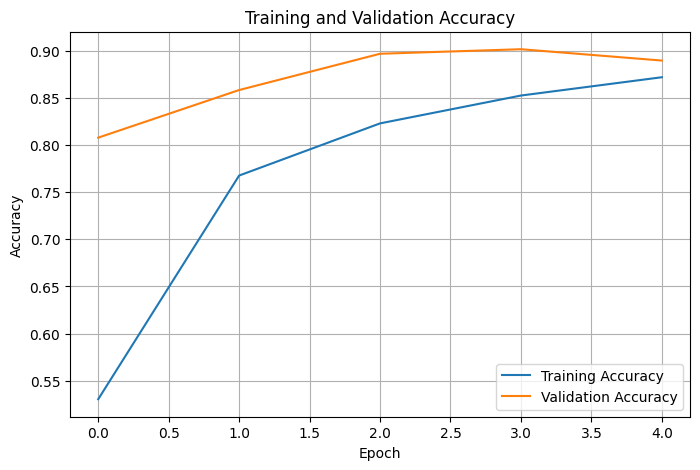

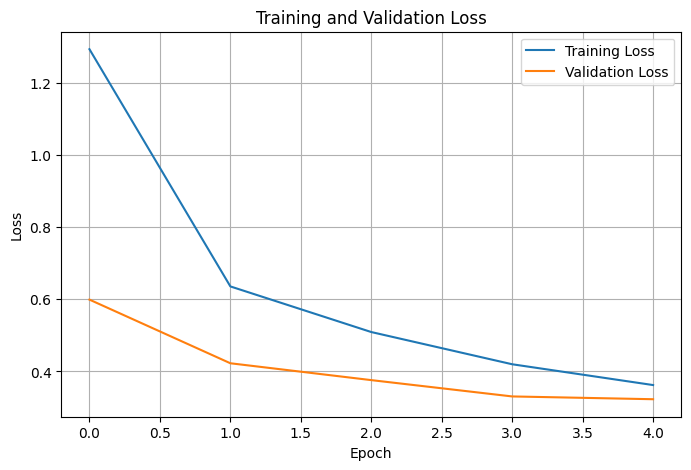

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


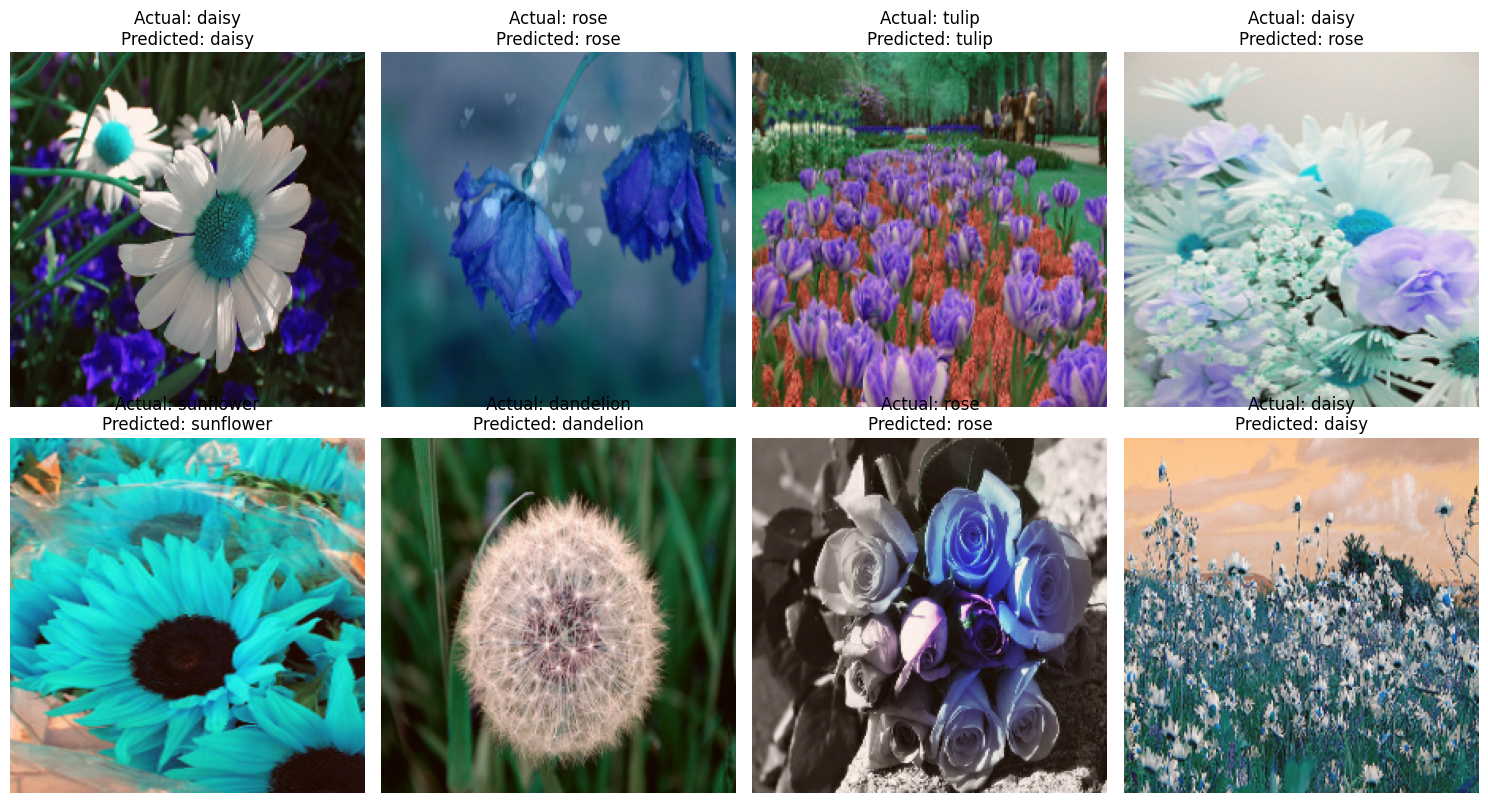


Task C completed successfully.


In [7]:
# EXPERIMENT NO: 4
# Task C: MODEL TRAINING AND PERFORMANCE EVALUATION
# Student Name: Preethi R
# Roll No: 24BAD091

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

print("Preethi R - 24BAD091")

# Apply ResNet-50 preprocessing
def preprocess_images(images, labels):
    images = preprocess_input(images)
    return images, labels

train_data = train_dataset.map(
    preprocess_images,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_data = validation_dataset.map(
    preprocess_images,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_data = test_dataset.map(
    preprocess_images,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Improve data pipeline performance
train_data = train_data.prefetch(tf.data.AUTOTUNE)
validation_data = validation_data.prefetch(tf.data.AUTOTUNE)
test_data = test_data.prefetch(tf.data.AUTOTUNE)

# Train the model
EPOCHS = 5

history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=EPOCHS
)

# Evaluate on test dataset
test_loss, test_accuracy = model.evaluate(test_data)

print("\nModel Evaluation")
print("-----------------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

# Print training results
print("\nTraining Results")
print("-----------------------------")

for epoch in range(EPOCHS):
    print(
        f"Epoch {epoch + 1}: "
        f"Training Accuracy = {history.history['accuracy'][epoch] * 100:.2f}%, "
        f"Validation Accuracy = {history.history['val_accuracy'][epoch] * 100:.2f}%, "
        f"Training Loss = {history.history['loss'][epoch]:.4f}, "
        f"Validation Loss = {history.history['val_loss'][epoch]:.4f}"
    )

# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# Display predictions on sample test images
images, labels = next(iter(test_data))

predictions = model.predict(images)

predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(labels.numpy(), axis=1)

plt.figure(figsize=(15, 8))

for i in range(min(8, len(images))):

    # Convert image back approximately for display
    image = images[i].numpy()
    image = image - image.min()
    image = image / image.max()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)

    actual = class_names[actual_classes[i]]
    predicted = class_names[predicted_classes[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print("\nTask C completed successfully.")

Task D: USING HUGGING FACE PRE-TRAINED MODELS

Perform the following tasks:

    •	Load a pre-trained vision model from Hugging Face.
    •	Perform image classification on sample images.
    •	Compare predictions with the transfer learning model.
    •	Document observations and upload the notebook to GitHub.


Preethi R - 24BAD091


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

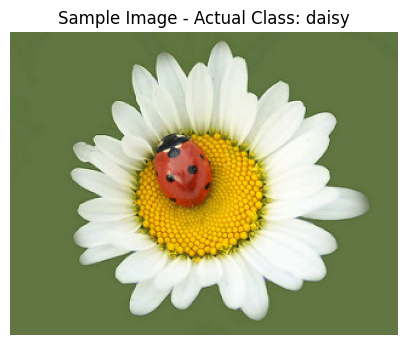


Hugging Face ViT Predictions
-----------------------------
ladybug, ladybeetle, lady beetle, ladybird, ladybird beetle : 75.14%
daisy : 23.09%
leaf beetle, chrysomelid : 0.61%
tick : 0.14%
weevil : 0.05%

ResNet-50 Transfer Learning Prediction
---------------------------------------
Predicted Class : daisy
Confidence      : 96.85%

Observation
-----------
The Hugging Face ViT model is a pre-trained ImageNet classifier.
The ResNet-50 model has been trained specifically for the five flower classes.
Therefore, their labels may differ, but both models demonstrate the use
of pre-trained vision models for image classification.

Task D completed successfully.


In [8]:
# EXPERIMENT NO: 4
# Task D: USING HUGGING FACE PRE-TRAINED MODELS
# Student Name: Preethi R
# Roll No: 24BAD091

!pip -q install transformers

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import pipeline
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

print("Preethi R - 24BAD091")

# Load Hugging Face pre-trained Vision Transformer
hf_classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

# Select one sample image from the dataset
sample_class = class_names[0]

sample_class_path = os.path.join(
    dataset_path,
    sample_class
)

sample_images = [
    file for file in os.listdir(sample_class_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
]

sample_image_path = os.path.join(
    sample_class_path,
    sample_images[0]
)

# Open image
image = Image.open(sample_image_path).convert("RGB")

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f"Sample Image - Actual Class: {sample_class}")
plt.axis("off")
plt.show()

# Hugging Face prediction
hf_results = hf_classifier(image)

print("\nHugging Face ViT Predictions")
print("-----------------------------")

for result in hf_results[:5]:
    print(
        f"{result['label']} : "
        f"{result['score'] * 100:.2f}%"
    )

# Prepare image for ResNet-50
image_resized = image.resize((224, 224))
image_array = np.array(image_resized)

image_batch = np.expand_dims(
    image_array,
    axis=0
)

image_batch = preprocess_input(image_batch)

# ResNet-50 prediction
resnet_prediction = model.predict(image_batch, verbose=0)

predicted_index = np.argmax(resnet_prediction[0])
predicted_class = class_names[predicted_index]
predicted_confidence = resnet_prediction[0][predicted_index]

print("\nResNet-50 Transfer Learning Prediction")
print("---------------------------------------")
print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {predicted_confidence * 100:.2f}%")

print("\nObservation")
print("-----------")
print("The Hugging Face ViT model is a pre-trained ImageNet classifier.")
print("The ResNet-50 model has been trained specifically for the five flower classes.")
print("Therefore, their labels may differ, but both models demonstrate the use")
print("of pre-trained vision models for image classification.")

print("\nTask D completed successfully.")